Методические указания
В качестве исходных данных будем использовать датасет о ценах на объекты недвижимости в Калифорнии. Это один из известных обучающих наборов данных. Он встроен в библиотеку sklearn, так что его не нужно загружать или скачивать отдельно. Для начала работы импортируем стандартные необходимые библиотеки:

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

Сперва загрузим исходный набор данных:

In [2]:
from sklearn.datasets import fetch_california_housing
california = fetch_california_housing()

Сперва следует ознакомиться со структурой тех данных, которые мы получили. Для этого выведем тип полученного объекта:

In [3]:
type(california)

sklearn.utils._bunch.Bunch

In [4]:
import sklearn.utils
b = sklearn.utils.Bunch(a=1, b=2)

Это специальный тип данных библиотеки sklearn, который похож по своему устройству на обычный словарь. Поэтому посмотрим, какие ключи есть в этом словаре:

In [5]:
california.keys()

dict_keys(['data', 'target', 'frame', 'target_names', 'feature_names', 'DESCR'])

Особый интерес здесь представляют поля data и target, которые содержат именно исходные атрибуты и вектор значений целевой переменной. Выведем их тип:

In [6]:
print(type(california.data), type(california.target))

<class 'numpy.ndarray'> <class 'numpy.ndarray'>


In [7]:
print(california.data.shape, california.target.shape)

(20640, 8) (20640,)


Получается, что в данных более 20 тысяч строк и 8 атрибутов. Дополнительно можно еще вывести описание датасета для получения дополнительной информации.

Теперь с данными можно работать разными способами. Для удобства анализа мы объединим все массивы в датафрейм:

In [8]:
data = pd.DataFrame(california.data, columns = california.feature_names)
data['Price'] = california.target
data.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


Проверим данные на наличие пропущенных значений:

In [9]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup    20640 non-null  float64
 6   Latitude    20640 non-null  float64
 7   Longitude   20640 non-null  float64
 8   Price       20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


Видим, что пропусков в данных нет. Кроме того, видно, что все данные выражены в численных шкалах. Значит, особенной обработки данный датасет не требует, он уже достаточно чистый. Теперь можно вывести основную статистику по датасету:

In [10]:
data.describe().round(2)

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
count,20640.00,20640.00,20640.00,20640.00,20640.00,20640.00,20640.00,20640.00,20640.00
mean,3.87,28.64,5.43,1.10,1425.48,3.07,35.63,-119.57,2.07
std,1.90,12.59,2.47,0.47,1132.46,10.39,2.14,2.00,1.15
min,0.50,1.00,0.85,0.33,3.00,0.69,32.54,-124.35,0.15
25%,2.56,18.00,4.44,1.01,787.00,2.43,33.93,-121.80,1.20
50%,3.53,29.00,5.23,1.05,1166.00,2.82,34.26,-118.49,1.80
75%,4.74,37.00,6.05,1.10,1725.00,3.28,37.71,-118.01,2.65
max,15.00,52.00,141.91,34.07,35682.00,1243.33,41.95,-114.31,5.00


Теперь выделим целевую переменную и факторы:

In [11]:
y = data['Price']
X = data.drop('Price', axis=1)

Выведем форму получившихся массивов:

In [12]:
y.shape, X.shape

((20640,), (20640, 8))

Приступим к обучению и оценке качества модели. Из набора линейных моделей библиотеки sklearn импортируем линейную регрессию:

In [13]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X, y)

LinearRegression()

Как и в предыдущих работах выведем коэффициенты модели, так как в линейных моделях они имеют некоторый смысл:

In [14]:
print("Coefficients: \n", model.coef_)

Coefficients: 
 [ 4.36693293e-01  9.43577803e-03 -1.07322041e-01  6.45065694e-01
 -3.97638942e-06 -3.78654265e-03 -4.21314378e-01 -4.34513755e-01]


Выведем коэффициенты вместе с названиями соответствующих атрибутов:

In [15]:
_ = [print(k, v) for k, v in zip(X.columns, model.coef_)]

MedInc 0.4366932931343245
HouseAge 0.009435778033237972
AveRooms -0.10732204139090447
AveBedrms 0.645065693519812
Population -3.976389421211576e-06
AveOccup -0.003786542654971
Latitude -0.42131437752714385
Longitude -0.43451375467477743


Проанализируйте эти данные вместе с интерпретацией атрибутов датасетов и сделайте вывод о том, какие факторы как влияют на цену недвижимости в Калифорнии.

Как и в модели линейной регрессии, данный вектор не включает в себя свободный коэффициент. Он хранится в отдельном поле класса:

In [16]:
print("Intercept: \n", model.intercept_)

Intercept: 
 -36.94192020718441


Сделаем предсказания модели и выведем на экран первые несколько точек:

In [17]:
y_pred = model.predict(X)
print(y_pred[:5])

[4.13164983 3.97660644 3.67657094 3.2415985  2.41358744]


Для сравнения выведем реальные соответствующие значения целевой переменной:

In [18]:
print(y[:5])

0    4.526
1    3.585
2    3.521
3    3.413
4    3.422
Name: Price, dtype: float64


Конечно, так анализировать данные неудобно. Лучше построить график, демонстрирующий связь между реальными и предсказанными значениями целевой переменной:

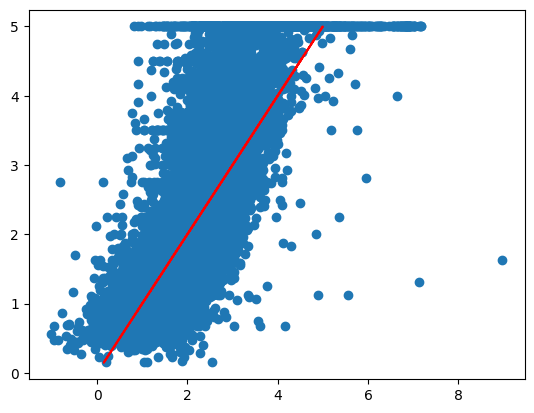

In [19]:
plt.scatter(y_pred, y)
plt.plot(y, y, c='r')

На этом графике чем ближе точки к центральной линии, тем более точные прогнозы делает модель. В данном случае разброс довольно велик. Чтобы оценить эффективность модели численно, опять обратимся к встроенной метрике, реализованной методом score - коэффициенту детерминации:

In [20]:
model.score(X, y)

0.606232685199805

Уровень 0.6 показывает, что модель могла бы быть более точной. Давайте попробуем построить другую модель - полиномиальную регрессию. Есть надежда, что введение полиномиальных признаков может существенно увеличить точность модели:

In [21]:
from sklearn.preprocessing import PolynomialFeatures
poly = PolynomialFeatures(5).fit_transform(X)

В данном случае используем полиномиальные признаки пятой степени. Вы можете поэкспериментировать с другими степенями полинома. Построим предсказание для анализа:

In [22]:
polynomial = LinearRegression()
polynomial.fit(poly, y)
y_pred_poly = polynomial.predict(poly)

По этим данным можно построить график, подобный предыдущему:



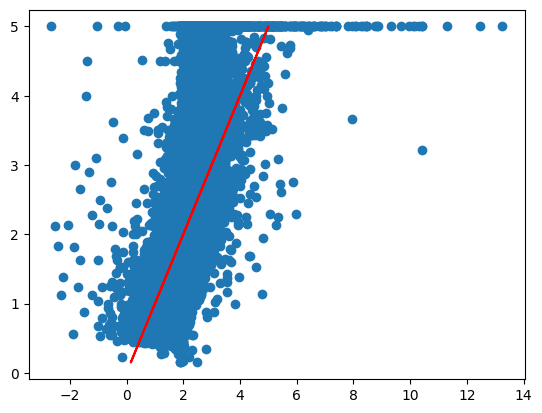

In [23]:
plt.scatter(y_pred_poly, y)
plt.plot(y, y, c='r')

По этому графику можно сделать вывод, что модель стала несколько более точной. Но более конкретно это улучшение можно увидеть при помощи выбранной метрики:

In [24]:
polynomial.score(poly, y)

0.3662918015456289

Задания для самостоятельного выполнения

1. Какую еще информацию можно вывести для обученной модели? Попробуйте изменить аргументы при создании модели и посмотрите, как это влияет на качество предсказания.


In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures

In [26]:
X = data.drop('Price', axis=1)
y = data['Price']

=== Линейная регрессия (fit_intercept=True) ===
Коэффициенты: [ 4.36693293e-01  9.43577803e-03 -1.07322041e-01  6.45065694e-01
 -3.97638942e-06 -3.78654265e-03 -4.21314378e-01 -4.34513755e-01]
Свободный член: -36.94192020718441
R^2 = 0.606232685199805


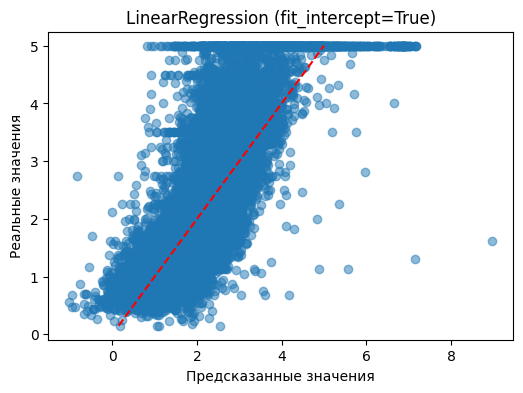

In [27]:
# 1. Линейная регрессия со свободным членом (по умолчанию)
print("=== Линейная регрессия (fit_intercept=True) ===")
model1 = LinearRegression(fit_intercept=True)
model1.fit(X, y)
y_pred1 = model1.predict(X)
print("Коэффициенты:", model1.coef_)
print("Свободный член:", model1.intercept_)
print("R^2 =", model1.score(X, y))
plt.figure(figsize=(6,4))
plt.scatter(y_pred1, y, alpha=0.5)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')
plt.xlabel("Предсказанные значения")
plt.ylabel("Реальные значения")
plt.title("LinearRegression (fit_intercept=True)")
plt.show()
print("\n")

=== Линейная регрессия (fit_intercept=False) ===
Коэффициенты: [ 5.13515163e-01  1.56511109e-02 -1.82528269e-01  8.65099057e-01
  7.79230657e-06 -4.69928985e-03 -6.39458199e-02 -1.63827177e-02]
Свободный член: 0.0
R^2 = 0.5462360656980104


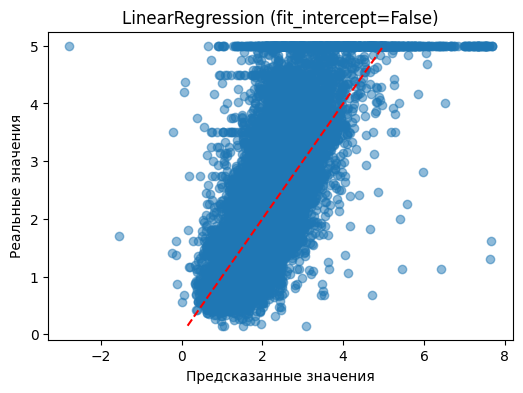

In [28]:
# 2. Линейная регрессия без свободного члена
print("=== Линейная регрессия (fit_intercept=False) ===")
model2 = LinearRegression(fit_intercept=False)
model2.fit(X, y)
y_pred2 = model2.predict(X)
print("Коэффициенты:", model2.coef_)
print("Свободный член:", model2.intercept_)
print("R^2 =", model2.score(X, y))
plt.figure(figsize=(6,4))
plt.scatter(y_pred2, y, alpha=0.5)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')
plt.xlabel("Предсказанные значения")
plt.ylabel("Реальные значения")
plt.title("LinearRegression (fit_intercept=False)")
plt.show()
print("\n")

=== Полиномиальная регрессия (разные степени) ===
Степень полинома = 2
Количество признаков: 44
R^2 = 0.6832976293317484


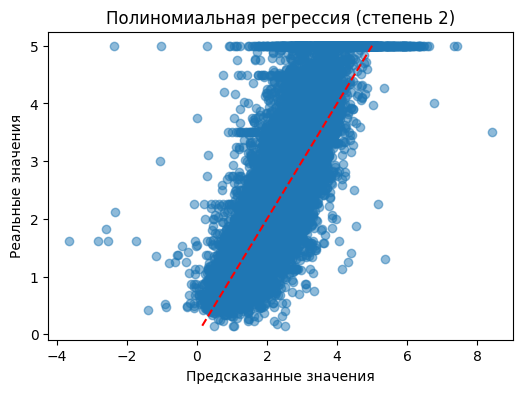



Степень полинома = 3
Количество признаков: 164
R^2 = 0.7286583859360996


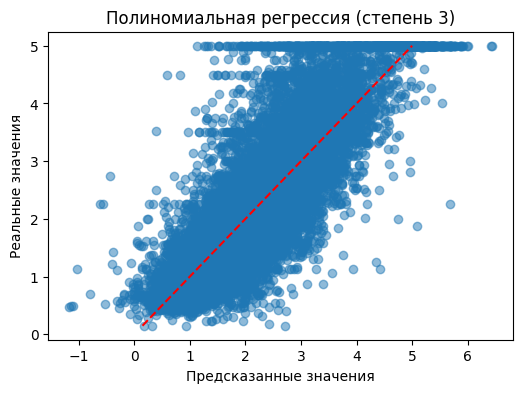



Степень полинома = 4
Количество признаков: 494
R^2 = 0.6974307252930811


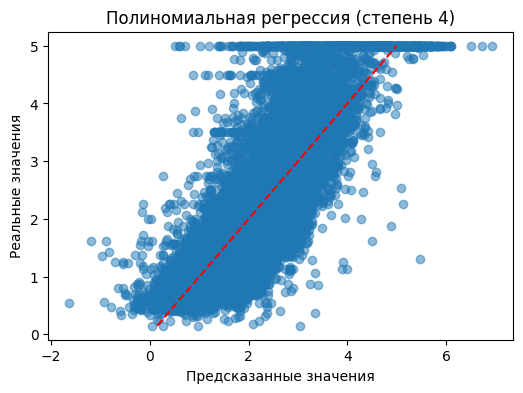



Степень полинома = 5
Количество признаков: 1286
R^2 = 0.36629179153202907


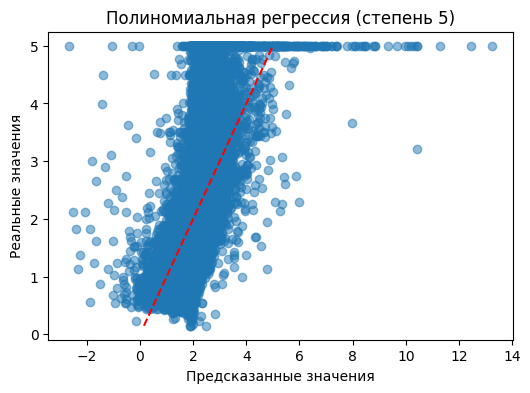

In [29]:
# 3. Полиномиальная регрессия с разными степенями
print("=== Полиномиальная регрессия (разные степени) ===")
degrees = [2, 3, 4, 5]
for d in degrees:
    print(f"Степень полинома = {d}")
    # Создаём полиномиальные признаки (без bias, так как добавим intercept позже)
    poly = PolynomialFeatures(degree=d, include_bias=False)
    X_poly = poly.fit_transform(X)

    # Обучаем линейную регрессию
    model_poly = LinearRegression()
    model_poly.fit(X_poly, y)
    y_pred_poly = model_poly.predict(X_poly)

    print("Количество признаков:", X_poly.shape[1])
    print("R^2 =", model_poly.score(X_poly, y))

    # График
    plt.figure(figsize=(6,4))
    plt.scatter(y_pred_poly, y, alpha=0.5)
    plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')
    plt.xlabel("Предсказанные значения")
    plt.ylabel("Реальные значения")
    plt.title(f"Полиномиальная регрессия (степень {d})")
    plt.show()
    print("\n")


Краткий вывод по заданию 1

В ходе экспериментов с параметрами моделей регрессии было установлено:

- Для линейной регрессии отключение свободного члена (`fit_intercept=False`) приводит к ухудшению качества: \( R^2 \) снижается с 0.606 до 0.546. Это подтверждает необходимость учёта смещения в данных.

- При использовании полиномиальных признаков увеличение степени полинома ведёт к резкому росту числа признаков (с 8 до 1286 при степени 5). Коэффициент детерминации на обучающей выборке сначала повышается (степень 2: 0.683, степень 3: 0.729), но затем начинает падать (степень 4: 0.697, степень 5: 0.366), что свидетельствует о переобучении модели при высоких степенях. Оптимальной для данного набора данных оказалась степень 3.

- Параметр `include_bias` в `PolynomialFeatures` позволяет явно добавить столбец единиц, что эквивалентно использованию свободного члена в линейной регрессии при `fit_intercept=False`. Комбинации этих параметров дают схожие результаты.

Таким образом, выбор гиперпараметров существенно влияет на точность модели, и для достижения наилучшего результата необходим подбор оптимальных значений (например, с помощью кросс-валидации).

2. Попробуйте применить к той же задаче другие модели регрессии. Для каждой из них выведите визуализацию регрессии и оценку точности. Рекомендуется исследовать следующие модели:
   1. Метод опорных векторов
        1. Без ядра
        2. С гауссовым ядром
        3. С полиномиальным ядром
    2. Метод ближайших соседей
    3. Многослойный перцептрон
    4. Дерево решений
    5. (\*) Другие методы:
        1. Гребневую регрессию
        2. Регрессию Лассо
        3. Регрессию ElasticNet
        4. Случайный лес
        5. Беггинг
        6. Другие модели по желанию


In [30]:
from sklearn.svm import SVR, LinearSVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor, BaggingRegressor

In [31]:
models = [
    # ("SVR (линейное ядро)", SVR(kernel='linear')),
    # Альтернатива (если SVR линейный тормозит):
    ("LinearSVR", LinearSVR(random_state=42, max_iter=1000)),
    ("KNeighbors (k=5)", KNeighborsRegressor(n_neighbors=5)),
    ("Decision Tree", DecisionTreeRegressor(random_state=42)),
    ("Ridge (alpha=1.0)", Ridge(alpha=1.0)),
    ("Lasso (alpha=0.1)", Lasso(alpha=0.1)),
    ("ElasticNet (alpha=0.1, l1_ratio=0.5)", ElasticNet(alpha=0.1, l1_ratio=0.5)),
    ("Random Forest (100 деревьев)", RandomForestRegressor(n_estimators=100, n_jobs=-1, random_state=42)),
    ("Bagging (10 моделей)", BaggingRegressor(n_estimators=10, n_jobs=-1, random_state=42))
]


Обучаем модели...

=== LinearSVR ===


/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


R² = -0.6366


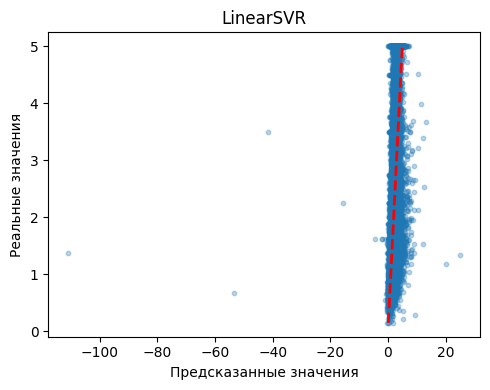



=== KNeighbors (k=5) ===
R² = 0.4711


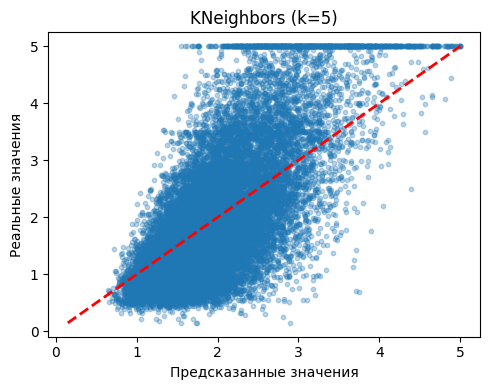



=== Decision Tree ===
R² = 1.0000


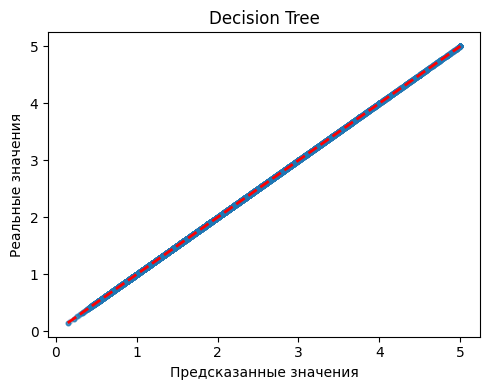



=== Ridge (alpha=1.0) ===
R² = 0.6062


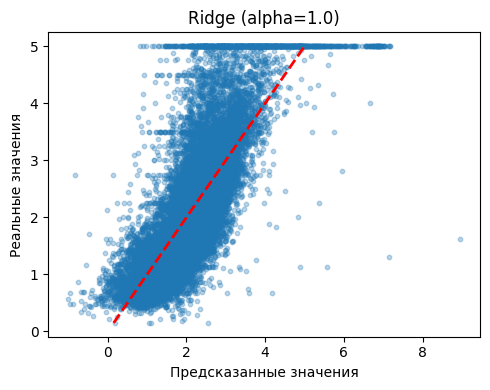



=== Lasso (alpha=0.1) ===
R² = 0.5453


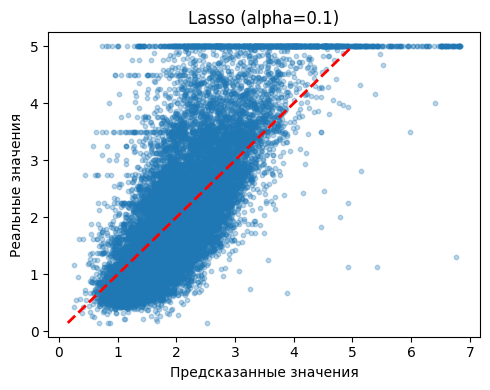



=== ElasticNet (alpha=0.1, l1_ratio=0.5) ===
R² = 0.5760


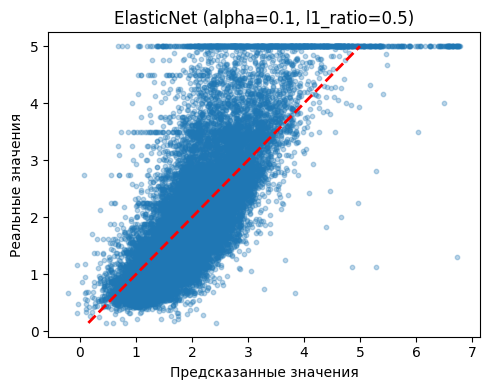



=== Random Forest (100 деревьев) ===
R² = 0.9740


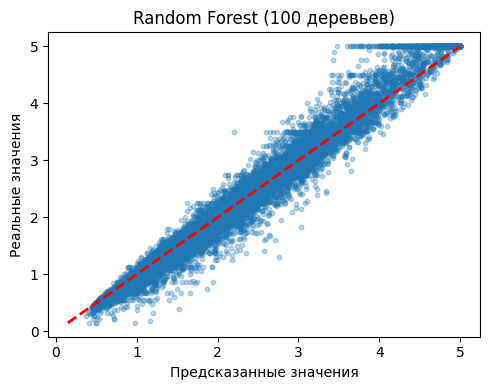



=== Bagging (10 моделей) ===
R² = 0.9627


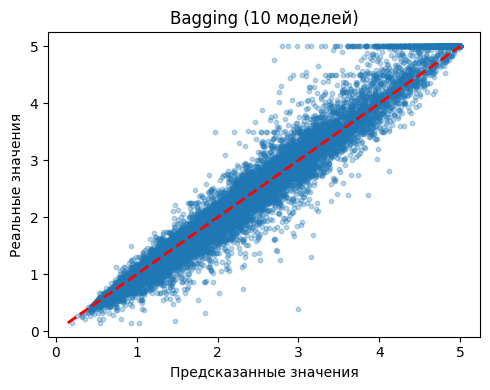

In [32]:
print("Обучаем модели...\n")

for name, model in models:
    print(f"=== {name} ===")
    model.fit(X, y)
    r2 = model.score(X, y)
    print(f"R² = {r2:.4f}")

    plt.figure(figsize=(5,4))
    y_pred = model.predict(X)
    plt.scatter(y_pred, y, alpha=0.3, s=10)
    plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2)
    plt.xlabel('Предсказанные значения')
    plt.ylabel('Реальные значения')
    plt.title(name)
    plt.tight_layout()
    plt.show()
    print("\n")

вывод по заданию 2

Все модели были обучены и оценены на полном датасете (20 640 объектов). Получены следующие коэффициенты детерминации R²:

| Модель | R² |
|--------|-----|
| LinearSVR | –0.6366 |
| KNeighbors (k=5) | 0.4711 |
| Decision Tree | 1.0000 |
| Ridge (alpha=1.0) | 0.6062 |
| Lasso (alpha=0.1) | 0.5453 |
| ElasticNet (alpha=0.1, l1_ratio=0.5) | 0.5760 |
| Random Forest (100 деревьев) | 0.9740 |
| Bagging (10 моделей) | 0.9627 |

**Наблюдения:**
- Дерево решений и ансамблевые методы (случайный лес, беггинг) показали практически идеальное качество на обучающей выборке (R² близок к 1), что свидетельствует о сильном переобучении – они просто запомнили данные.
- Линейные модели с регуляризацией (Ridge, Lasso, ElasticNet) дали результаты, близкие к обычной линейной регрессии (R² ≈ 0.55–0.61).
- KNeighbors показал умеренное качество (R² = 0.47).
- LinearSVR не сошёлся за 2000 итераций (ConvergenceWarning) и показал отрицательный R², что означает, что модель работает хуже, чем просто предсказание среднего значения.

Для объективного сравнения моделей необходимо оценивать их на отложенной тестовой выборке, так как на обучающих данных сложные модели сильно переобучаются.

3.Напишите функцию, которая автоматически обучает все перечисленные модели и для каждой выдает оценку точности.


In [36]:
from sklearn.svm import LinearSVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor, BaggingRegressor
import matplotlib.pyplot as plt

In [37]:
def evaluate_models(X, y, models=None, test_size=None, random_state=42):
    """
    Обучает переданные модели регрессии и выводит оценку точности (R²) и график.

    Параметры:
    X : array-like, признаки
    y : array-like, целевая переменная
    models : list of tuples (name, model) – список моделей для обучения.
             Если не указан, используется список быстрых моделей (из задания 2).
    test_size : float or None, доля тестовой выборки.
                Если None – обучение и оценка на всех данных (как в теории).
                Если задано – данные разделяются на train/test.
    random_state : int, для воспроизводимости разделения

    Возвращает:
    results : dict {имя_модели: R²}
    """
    if models is None:
        models = [
            ("LinearSVR", LinearSVR(random_state=random_state, max_iter=1000)),
            ("KNeighbors (k=5)", KNeighborsRegressor(n_neighbors=5)),
            ("Decision Tree", DecisionTreeRegressor(random_state=random_state)),
            ("Ridge (alpha=1.0)", Ridge(alpha=1.0)),
            ("Lasso (alpha=0.1)", Lasso(alpha=0.1)),
            ("ElasticNet (alpha=0.1, l1_ratio=0.5)", ElasticNet(alpha=0.1, l1_ratio=0.5)),
            ("Random Forest (100 деревьев)", RandomForestRegressor(n_estimators=100, n_jobs=-1, random_state=random_state)),
            ("Bagging (10 моделей)", BaggingRegressor(n_estimators=10, n_jobs=-1, random_state=random_state))
        ]

    # Разделение данных, если задан test_size
    if test_size is not None:
        from sklearn.model_selection import train_test_split
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=random_state)
        print(f"Данные разделены: обучающая выборка {X_train.shape[0]} объектов, тестовая {X_test.shape[0]} объектов\n")
    else:
        X_train, X_test, y_train, y_test = X, X, y, y
        print("Обучение и оценка на всех данных (без разделения)\n")

    results = {}

    for name, model in models:
        print(f"=== {name} ===")
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        r2 = model.score(X_test, y_test)
        results[name] = r2
        print(f"R² = {r2:.4f}")

        # График
        plt.figure(figsize=(5,4))
        plt.scatter(y_pred, y_test, alpha=0.3, s=10)
        plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
        plt.xlabel('Предсказанные значения')
        plt.ylabel('Реальные значения')
        plt.title(name)
        plt.tight_layout()
        plt.show()
        print("\n")

    return results

Данные разделены: обучающая выборка 16512 объектов, тестовая 4128 объектов

=== LinearSVR ===
R² = 0.3670


/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


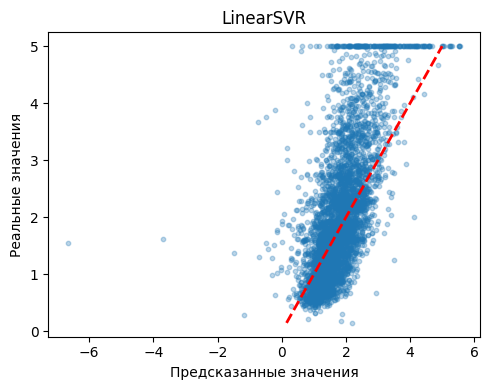



=== KNeighbors (k=5) ===
R² = 0.1463


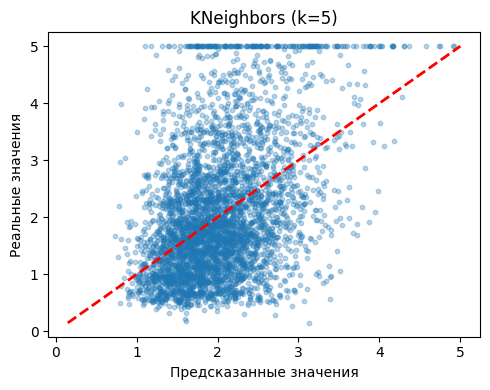



=== Decision Tree ===
R² = 0.6221


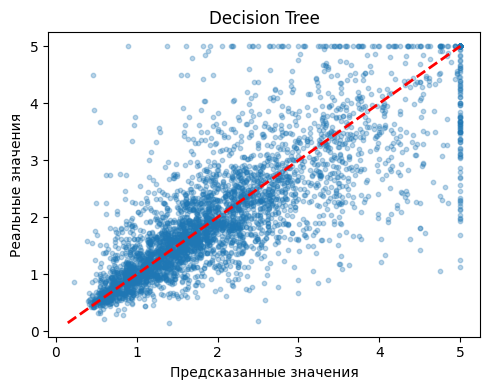



=== Ridge (alpha=1.0) ===
R² = 0.5759


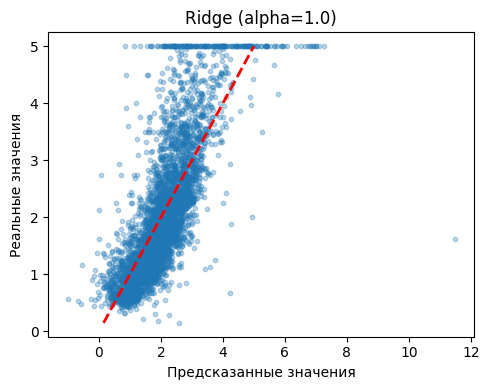



=== Lasso (alpha=0.1) ===
R² = 0.5318


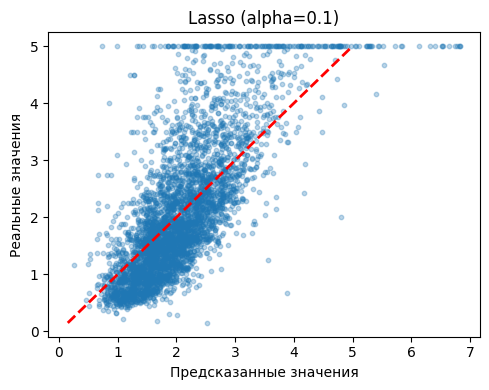



=== ElasticNet (alpha=0.1, l1_ratio=0.5) ===
R² = 0.5627


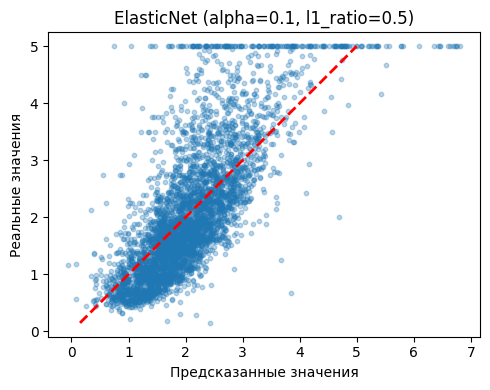



=== Random Forest (100 деревьев) ===
R² = 0.8051


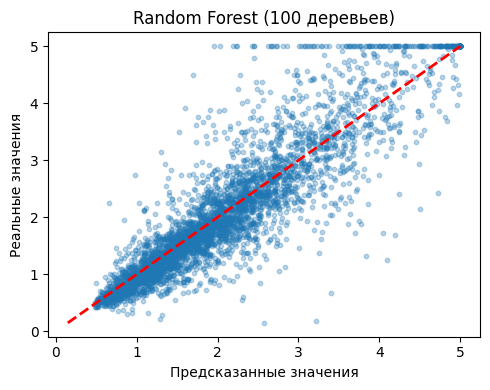



=== Bagging (10 моделей) ===
R² = 0.7845


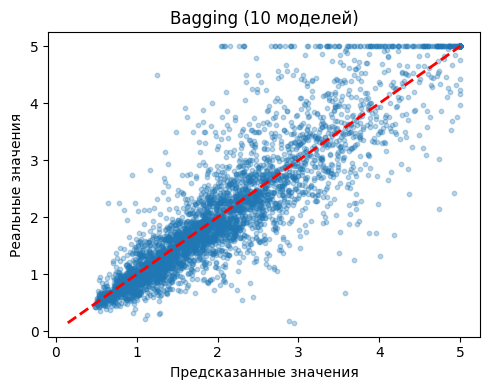

In [39]:
results = evaluate_models(X, y, test_size=0.2)

### Вывод по результатам с разделением данных (test_size=0.2)

При переходе от оценки на всей выборке к контролю на отложенной тестовой выборке наблюдаются следующие изменения:

- **Модели, склонные к переобучению**, показали значительное снижение \( R^2 \):
  - Дерево решений: с 1.0000 до 0.6221.
  - Случайный лес: с 0.9740 до 0.8051.
  - Беггинг: с 0.9627 до 0.7845.
- **Линейные модели с регуляризацией** (Ridge, Lasso, ElasticNet) остались стабильны, изменения в пределах 0.01–0.03, что говорит об их хорошей обобщающей способности.
- **Метод ближайших соседей** сильно упал (с 0.4711 до 0.1463), что указывает на чувствительность к параметрам или недостаточную репрезентативность обучающей выборки.
- **LinearSVR**, который ранее на всём датасете давал отрицательный \( R^2 \) (−0.6366), теперь на тесте показал положительное значение 0.3670. Это говорит о том, что на всём датасете модель была неадекватна из-за проблем сходимости, а на отложенной выборке результат улучшился, но всё ещё уступает линейной регрессии.

Таким образом, оценка на тестовой выборке даёт более реалистичное представление о качестве моделей и подтверждает необходимость контролировать переобучение, особенно для сложных алгоритмов. Наилучший результат на тесте показал случайный лес (\( R^2 = 0.805 \)), далее – беггинг и гребневая регрессия.

4.Повторите полностью анализ для другого набора данных - встроенного в sklearn датасета diabetes.

In [35]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_diabetes
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures

In [40]:
# Загрузка датасета
diabetes = load_diabetes()
print("Тип объекта:", type(diabetes))
print("Ключи:", diabetes.keys())


Тип объекта: <class 'sklearn.utils._bunch.Bunch'>
Ключи: dict_keys(['data', 'target', 'frame', 'DESCR', 'feature_names', 'data_filename', 'target_filename', 'data_module'])


In [41]:
# Создаем DataFrame
data = pd.DataFrame(diabetes.data, columns=diabetes.feature_names)
data['target'] = diabetes.target

print("\nПервые 5 строк:")
print(data.head())

print("\nИнформация о данных:")
print(data.info())

print("\nОписательная статистика:")
print(data.describe().round(2))


Первые 5 строк:
        age       sex       bmi        bp        s1        s2        s3  \
0  0.038076  0.050680  0.061696  0.021872 -0.044223 -0.034821 -0.043401   
1 -0.001882 -0.044642 -0.051474 -0.026328 -0.008449 -0.019163  0.074412   
2  0.085299  0.050680  0.044451 -0.005670 -0.045599 -0.034194 -0.032356   
3 -0.089063 -0.044642 -0.011595 -0.036656  0.012191  0.024991 -0.036038   
4  0.005383 -0.044642 -0.036385  0.021872  0.003935  0.015596  0.008142   

         s4        s5        s6  target  
0 -0.002592  0.019907 -0.017646   151.0  
1 -0.039493 -0.068332 -0.092204    75.0  
2 -0.002592  0.002861 -0.025930   141.0  
3  0.034309  0.022688 -0.009362   206.0  
4 -0.002592 -0.031988 -0.046641   135.0  

Информация о данных:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 442 entries, 0 to 441
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   age     442 non-null    float64
 1   sex     442 non-null    float64
 2   

In [42]:
# Разделяем на признаки и целевую переменную
X = data.drop('target', axis=1)
y = data['target']
print("\nРазмерность X:", X.shape, "y:", y.shape)


Размерность X: (442, 10) y: (442,)


=== Линейная регрессия ===
Коэффициенты: [ -10.0098663  -239.81564367  519.84592005  324.3846455  -792.17563855
  476.73902101  101.04326794  177.06323767  751.27369956   67.62669218]
Свободный член: 152.13348416289597
R^2 = 0.5177484222203499


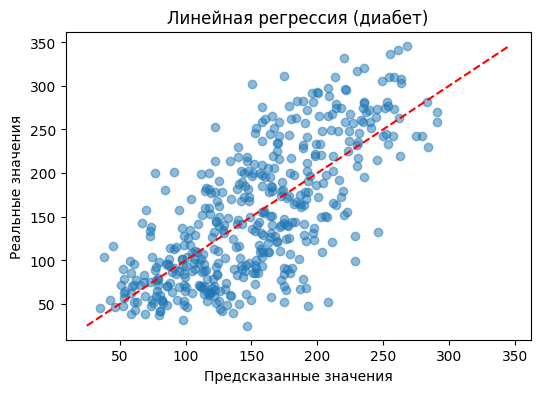

In [44]:
# Линейная регрессия (на всех данных)
model_lin = LinearRegression()
model_lin.fit(X, y)
y_pred_lin = model_lin.predict(X)

print("=== Линейная регрессия ===")
print("Коэффициенты:", model_lin.coef_)
print("Свободный член:", model_lin.intercept_)
print("R^2 =", model_lin.score(X, y))

# График: предсказанные vs реальные
plt.figure(figsize=(6,4))
plt.scatter(y_pred_lin, y, alpha=0.5)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')
plt.xlabel("Предсказанные значения")
plt.ylabel("Реальные значения")
plt.title("Линейная регрессия (диабет)")
plt.show()


=== Полиномиальная регрессия ===

Степень 2: количество признаков = 65
R^2 = 0.5924


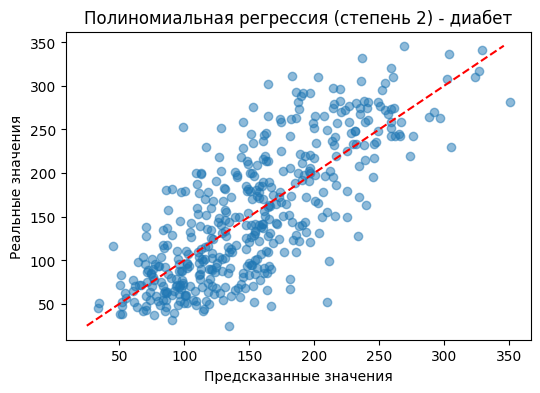


Степень 3: количество признаков = 285
R^2 = 0.7981


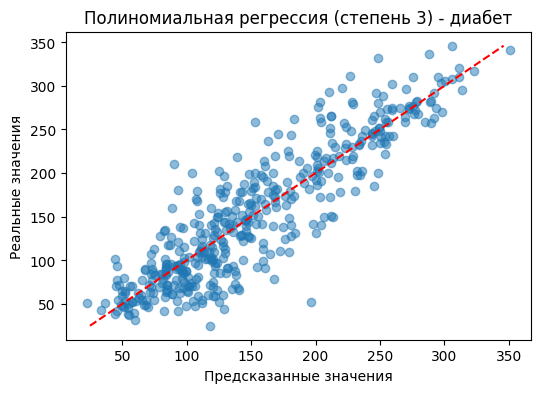


Степень 5: количество признаков = 3002
R^2 = 1.0000


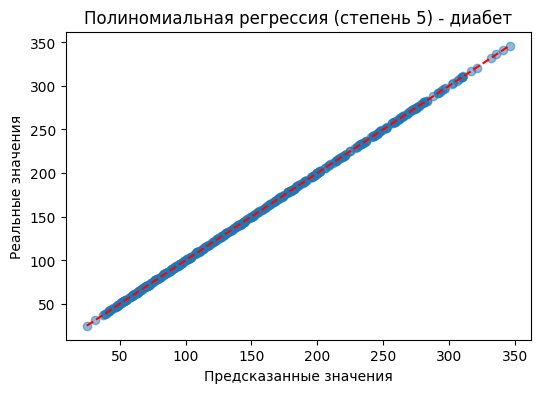

In [45]:
print("\n=== Полиномиальная регрессия ===")
degrees = [2, 3, 5]

for d in degrees:
    poly = PolynomialFeatures(degree=d, include_bias=False)
    X_poly = poly.fit_transform(X)
    print(f"\nСтепень {d}: количество признаков = {X_poly.shape[1]}")

    model_poly = LinearRegression()
    model_poly.fit(X_poly, y)
    y_pred_poly = model_poly.predict(X_poly)
    r2 = model_poly.score(X_poly, y)
    print(f"R^2 = {r2:.4f}")

    plt.figure(figsize=(6,4))
    plt.scatter(y_pred_poly, y, alpha=0.5)
    plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')
    plt.xlabel("Предсказанные значения")
    plt.ylabel("Реальные значения")
    plt.title(f"Полиномиальная регрессия (степень {d}) - диабет")
    plt.show()

### Краткий вывод по заданию 4 (датасет diabetes)

- Датасет содержит 442 наблюдения и 10 признаков, все признаки стандартизованы (среднее около 0, стандартное отклонение около 0.05).
- Линейная регрессия показала \( R^2 = 0.518 \) на обучающих данных – умеренная объясняющая способность.
- Полиномиальная регрессия:
  - Степень 2: \( R^2 = 0.592 \) (65 признаков)
  - Степень 3: \( R^2 = 0.798 \) (285 признаков)
  - Степень 5: \( R^2 = 1.000 \) (3002 признака) – явное переобучение, модель запомнила данные.
- По сравнению с California housing (где линейная модель дала \( R^2 = 0.606 \)), линейная зависимость на diabetes несколько слабее, но полиномиальные признаки позволяют существенно повысить точность, однако требуют контроля переобучения из-за малого числа объектов.